# 第5回 Pythonセミナー 課題

## 糖尿病データセットを用いたクラス分類（kNN と Random Forest）

このノートブックでは、Pima Indians Diabetes データセットを使って
**「ある人が糖尿病かどうか（Outcome = 0 / 1）」を予測する2クラス分類モデル**を作ります。

### このノートブックでやること
1. データを読み込んで中身を理解する（探索的データ分析 / EDA）
2. データの前処理（おかしな値の処理・標準化）
3. **kNN** と **Random Forest** でモデルを作る
4. それぞれ **デフォルト設定** と **ハイパーパラメータチューニング後** を比較する
5. 評価指標（混同行列・Accuracy・Precision・Recall・F1・ROC曲線・PR曲線）で性能を見る

> **検証方法について**
> 基本は **Hold-Out 検証**（データを「学習用」と「テスト用」に1回だけ分ける方法）を使います。
> チューニングのところだけ、より信頼できる **交差検証（Cross Validation, CV）** も使います。

データセットの出典: https://www.kaggle.com/datasets/saurabh00007/diabetescsv


## 1. ライブラリの読み込み

最初に、これから使う道具（ライブラリ）をまとめて読み込みます。

- **pandas / numpy**: 表形式データや数値計算を扱う
- **matplotlib / seaborn**: グラフ描画
- **scikit-learn (sklearn)**: 機械学習の本体（モデル・評価指標・前処理など）


In [1]:
# 数値計算・データ処理
import numpy as np
import pandas as pd

# 可視化
import matplotlib.pyplot as plt
import seaborn as sns

# 機械学習: データ分割・前処理
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold,
    RepeatedStratifiedKFold, cross_val_predict,
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# 機械学習: モデル
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# 機械学習: 評価指標
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

# 結果を毎回同じにするための乱数シード（再現性のため）
RANDOM_STATE = 42

# 日本語を表示できるフォントを優先して、グラフ全体の見た目を統一する
from matplotlib import font_manager

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
japanese_font_candidates = [
    "Hiragino Sans",       # macOS
    "Yu Gothic",           # Windows
    "Noto Sans CJK JP",    # Linux
    "IPAexGothic",
]
japanese_font = next(
    (font for font in japanese_font_candidates if font in available_fonts),
    "DejaVu Sans",
)

sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    font=japanese_font,
)
plt.rcParams.update({
    "font.family": japanese_font,
    "figure.dpi": 180,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "#FAFAFA",
    "axes.titleweight": "bold",
    "axes.titlesize": 11.5,
    "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8,
    "legend.title_fontsize": 8.5,
    "figure.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

print("ライブラリの読み込み完了")


ライブラリの読み込み完了


#### 🔍 コード解説：ライブラリの読み込み
- `import numpy as np` / `import pandas as pd`：数値計算（np）と表データ操作（pd）。以降 `np.`・`pd.` で呼び出す。
- `matplotlib.pyplot as plt` / `seaborn as sns`：グラフ描画。seaborn は matplotlib をきれいにした上位ラッパー。
- `from sklearn.model_selection import ...`：データ分割やCVの道具。
  - `train_test_split`＝学習用とテスト用に分ける、`GridSearchCV`＝総当たりでハイパラ探索、
    `StratifiedKFold`/`RepeatedStratifiedKFold`＝クラス比率を保ったCV、`cross_val_predict`＝CVでの予測取得。
- `StandardScaler`＝標準化、`SimpleImputer`＝欠損補完、`Pipeline`＝前処理とモデルを一括化。
- `KNeighborsClassifier`＝kNN、`RandomForestClassifier`＝ランダムフォレスト本体。
- `from sklearn.metrics import ...`：混同行列・Accuracy などの評価指標一式。
- `RANDOM_STATE = 42`：乱数の種。これを固定すると毎回同じ分割・同じ結果になり**再現性**が保てる。
- `sns.set_theme(...)` / `plt.rcParams[...]`：グラフの見た目（背景・解像度）をまとめて設定。

## 2. データの読み込みと確認

CSV ファイルを pandas で読み込みます。
`df`（DataFrame の略）という「表」のオブジェクトにデータが入ります。


In [2]:
# CSV を読み込む（このノートブックと同じ prac/ フォルダにある diabetes.csv）
df = pd.read_csv("diabetes.csv")

# 行数・列数を確認（(行数, 列数)）
print("データの形:", df.shape)

# 先頭5行を表示して中身を確認
df.head()


データの形: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


#### 🔍 コード解説：データの読み込み
- `pd.read_csv("diabetes.csv")`：CSVを読み込み、表（**DataFrame**）として `df` に格納。
- `df.shape`：`(行数, 列数)` のタプル。ここでは `(768, 9)`（8特徴量＋目的変数1）。
- `df.head()`：先頭5行を表示。セル最後に置いた変数は自動で表として描画される。

### 各列（特徴量）の意味

| 列名 | 意味 |
|------|------|
| Pregnancies | 妊娠回数 |
| Glucose | 血糖値（ブドウ糖負荷試験） |
| BloodPressure | 血圧 |
| SkinThickness | 皮膚の厚さ |
| Insulin | インスリン値 |
| BMI | 体格指数 |
| DiabetesPedigreeFunction | 糖尿病の家系度（遺伝的なリスク） |
| Age | 年齢 |
| **Outcome** | **目的変数：糖尿病なら1、そうでなければ0** |

`Outcome` が **正解ラベル（予測したいもの）**、それ以外の8列が **特徴量（予測の手がかり）** です。


In [3]:
# 各列のデータ型と欠損(NaN)の有無を確認
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


#### 🔍 コード解説：データ型と欠損の確認
- `df.info()`：各列の**データ型**（int/float）と**非欠損(non-null)件数**、メモリ使用量を一覧表示。
- non-null 件数が 768 未満なら欠損(NaN)がある列。今は全列768なので、この時点では欠損ゼロに見える
  （＝欠損が0で隠れている、という次の気づきにつながる）。

In [4]:
# 数値の要約統計（平均・最小・最大など）を確認
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### 🔍 コード解説：要約統計量の確認
- `df.describe()`：数値列ごとに件数・平均(mean)・標準偏差(std)・最小(min)・四分位(25/50/75%)・最大(max)を計算。
- 着目点は **min**：`Glucose` や `BMI` の最小が 0 になっている → 医学的にあり得ない値で、
  実際は**欠損が0で埋められている**サインだと読み取れる。

### ⚠️ ここで重要な気づき

`describe()` の結果をよく見ると、**Glucose（血糖値）や BMI、BloodPressure などの最小値が 0** になっています。

人間の血糖値や BMI が 0 になることは現実にはありえません。
これは「データが欠けている部分を、便宜上 0 で埋めてある」状態だと考えられます。

つまり **0 = 実質的な欠損値（測定なし）** なので、このまま使うとモデルが誤解してしまいます。
次のステップでこれを処理します。


## 3. 目的変数のバランス確認

分類問題では「正解ラベルの偏り（クラス不均衡）」を最初に見ておくことが大切です。
0 と 1 がどのくらいの割合であるかを確認します。


Outcome
0    500
1    268
Name: count, dtype: int64

割合:
Outcome
0    0.651
1    0.349
Name: count, dtype: float64


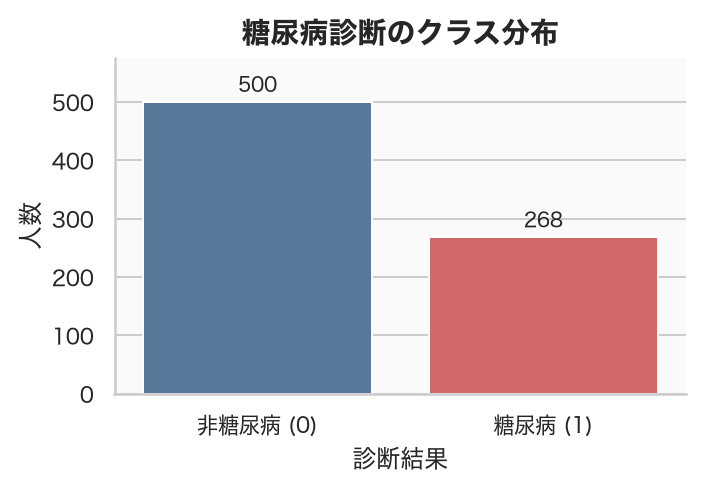

In [5]:
# Outcome の件数を数える
counts = df["Outcome"].value_counts().sort_index()
print(counts)
print("\n割合:")
print((counts / len(df)).round(3))

# 棒グラフで可視化（図は小さめに）
fig, ax = plt.subplots(figsize=(4, 2.8))
sns.countplot(x="Outcome", data=df, hue="Outcome", palette=["#4C78A8", "#E45756"], legend=False, ax=ax)
ax.set_title("糖尿病診断のクラス分布")
ax.set_xlabel("診断結果")
ax.set_ylabel("人数")
ax.set_xticks([0, 1], ["非糖尿病 (0)", "糖尿病 (1)"])
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=8)
ax.set_ylim(0, counts.max() * 1.15)
fig.tight_layout()
plt.show()

#### 🔍 コード解説：クラスの偏り（不均衡）の確認
- `df["Outcome"].value_counts()`：0と1の**件数**を数える。`.sort_index()` で0,1の順に並べる。
- `counts / len(df)`：件数を全体で割って**割合**に変換（約 0:65% / 1:35%）。
- `sns.countplot(...)`：件数を棒グラフ化。`hue="Outcome"` で色分け、`legend=False` で凡例を省略。
- `ax.bar_label(...)`：各棒の上に数値を表示。`ax.set_ylim(..., max*1.15)`：ラベルがはみ出ないよう上余白を確保。
- **狙い**：クラスが偏っているので、後でAccuracyだけでなくPrecision/Recall/F1も見る必要があると確認する。

**読み取り方**：糖尿病(1)の人は全体の約35%で、非糖尿病(0)が約65%。
完全に半々ではない（少し偏っている）ので、**Accuracy（正解率）だけで判断するのは危険**です。
後で Precision / Recall / F1 など複数の指標を見る理由がこれです。


## 4. データの前処理

### 4-1. 「0 = 欠損」を NaN に置き換える

医学的に 0 がありえない列について、0 を `NaN`（欠損値）に置き換えます。


In [6]:
# 0 を欠損として扱う列（妊娠回数は0が有り得るので除外する）
cols_zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# 0 を NaN に置換
df_clean = df.copy()
df_clean[cols_zero_as_missing] = df_clean[cols_zero_as_missing].replace(0, np.nan)

# 各列にどれくらい欠損があるか確認
print("各列の欠損数:")
print(df_clean.isna().sum())


各列の欠損数:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


#### 🔍 コード解説：「0=欠損」を NaN に置換
- `cols_zero_as_missing`：0を欠損として扱う列（妊娠回数 `Pregnancies` は0が正常なので除外）。
- `df_clean = df.copy()`：元データを壊さないようコピーしてから加工する（安全のため）。
- `.replace(0, np.nan)`：対象列の0を**欠損(NaN)**に置き換え。
- `df_clean.isna().sum()`：列ごとの欠損数を集計。`Insulin`・`SkinThickness` に多いと分かる。
- 補完(中央値で埋める)は後の **Pipeline 内**で行う（テスト情報の漏れ＝データリークを防ぐため）。

Insulin や SkinThickness は欠損がかなり多いことが分かります。
これらを「中央値」で埋める（補完する）方針にします。

> **なぜ中央値？** 平均値は極端な値（外れ値）に引っ張られやすいのに対し、
> 中央値は外れ値に強いため、医療データでよく使われます。
> なお、この補完は後述の **Pipeline の中で行う**ことで、
> 「テストデータの情報が学習に漏れる（データリーク）」のを防ぎます。


## 5. 特徴量と目的変数に分割 → Hold-Out で学習用/テスト用に分割

- **X**: 特徴量（8列） … 予測の手がかり
- **y**: 目的変数（Outcome） … 予測したい正解

これを **学習用(train) 80% と テスト用(test) 20%** に分けます（Hold-Out 検証）。

`stratify=y` を指定すると、train と test で 0:1 の比率が同じになるよう分割されます
（クラス不均衡なデータで重要）。


In [7]:
# 特徴量 X と 目的変数 y に分ける
X = df_clean.drop(columns="Outcome")
y = df_clean["Outcome"]

# 学習用80% / テスト用20% に分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # テストに回す割合
    random_state=RANDOM_STATE,  # 毎回同じ分け方にする
    stratify=y,           # クラス比率を保って分割
)

print("学習用:", X_train.shape, " テスト用:", X_test.shape)
print("学習用のOutcome比率:\n", y_train.value_counts(normalize=True).round(3))


学習用: (614, 8)  テスト用: (154, 8)
学習用のOutcome比率:
 Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


#### 🔍 コード解説：特徴量/目的変数の分割と Hold-Out 分割
- `X = df_clean.drop(columns="Outcome")`：目的変数以外の8列を**特徴量**に。`y = df_clean["Outcome"]`：**正解ラベル**。
- `train_test_split(...)`：データを学習用とテスト用に1回だけ分ける（**Hold-Out検証**）。
  - `test_size=0.2`：2割をテストへ。`random_state`：分け方を固定して再現性を確保。
  - `stratify=y`：分割後も 0:1 の比率を train/test で揃える（不均衡データで重要）。
- `value_counts(normalize=True)`：分割後の学習データでクラス比率が保たれているか確認。

### 前処理を Pipeline にまとめる理由

機械学習では「欠損の補完」や「標準化」といった前処理を行いますが、
これらは **学習データの統計量だけを使って** 行わなければいけません。
（テストデータの情報を使ってしまうと、テストでズルをしたことになり、性能を過大評価してしまう＝**データリーク**）

scikit-learn の **Pipeline** を使うと、
「補完 → 標準化 → モデル」を1つにまとめられ、リークを自動的に防げます。

- `SimpleImputer(strategy="median")`: 欠損を中央値で補完
- `StandardScaler()`: 各特徴量を平均0・分散1に標準化
  （**kNN は距離計算を使うので標準化が必須**。Random Forest には必須ではないが、付けても害はない）


## 6. 評価指標を計算する共通関数を用意

毎回同じ評価をするので、関数にまとめておきます。
ここで各指標の意味を確認しましょう。

混同行列（Confusion Matrix）は予測と正解の組み合わせを数えた表です。

|  | 予測=0 | 予測=1 |
|--|--------|--------|
| **実際=0** | TN (正しく陰性) | FP (誤って陽性) |
| **実際=1** | FN (見逃し) | TP (正しく陽性) |

- **Accuracy（正解率）** = (TP+TN) / 全体 … 全体でどれだけ当たったか
- **Precision（適合率）** = TP / (TP+FP) … 「陽性と予測したうち本当に陽性」の割合（誤検知の少なさ）
- **Recall（再現率）** = TP / (TP+FN) … 「本当に陽性のうち見つけられた」割合（見逃しの少なさ）
- **F1** = Precision と Recall の調和平均 … 両者のバランス

> 糖尿病の見逃し(FN)は危険なので、医療では特に **Recall** が重視されることが多いです。


In [8]:
def evaluate_model(model, X_te, y_te, model_name="model", show_plot=True):
    # 学習済みモデルをテストデータで評価し、各指標を表示する。
    # 予測は標準の判定閾値 0.5（確率0.5以上を陽性=1とする）で行う。
    # 戻り値: 指標をまとめた dict
    y_pred = model.predict(X_te)                 # 0.5閾値でのクラス予測
    y_proba = model.predict_proba(X_te)[:, 1]    # 陽性(1)である確率（ROC/PR曲線用）

    # 各指標を計算
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)

    print(f"===== {model_name} の評価 =====")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1       : {f1:.3f}")
    print("\n--- classification_report ---")
    print(classification_report(y_te, y_pred, target_names=["0:非糖尿病", "1:糖尿病"]))

    if show_plot:
        # 混同行列を図で表示（小さめ）
        cm = confusion_matrix(y_te, y_pred)
        fig, ax = plt.subplots(figsize=(3.6, 3))
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            xticklabels=["非糖尿病 (0)", "糖尿病 (1)"],
            yticklabels=["非糖尿病 (0)", "糖尿病 (1)"], ax=ax,
            annot_kws={"size": 10, "weight": "bold"},
        )
        ax.set_title(f"混同行列: {model_name}", fontsize=10)
        ax.set_xlabel("予測クラス")
        ax.set_ylabel("実際のクラス")
        fig.tight_layout()
        plt.show()

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "y_proba": y_proba,  # 後でROC/PR曲線に使う
    }

#### 🔍 コード解説：評価用の共通関数 `evaluate_model`
毎回同じ評価を繰り返すので関数にまとめている。
- `model.predict(X_te)`：**標準の0.5閾値**でのクラス予測（0/1）。
- `model.predict_proba(X_te)[:, 1]`：各サンプルが**陽性(1)である確率**。ROC/PR曲線で使う。
- `accuracy_score / precision_score / recall_score / f1_score`：4つの主要指標を計算。
- `classification_report(...)`：クラスごとの Precision/Recall/F1 をまとめて表示。
- `confusion_matrix(...)` ＋ `sns.heatmap(...)`：**混同行列**を色付きの表で可視化（`fmt="d"` は整数表示）。
- `return {...}`：あとで比較表やROC/PR曲線に使うため、指標と確率を辞書にまとめて返す。
- ポイント：以前あった「判定閾値を動かす引数」は廃止し、**0.5固定**にしてAccuracyを不必要に下げないようにした。

# === kNN（k近傍法） ===

## 7. kNN とは

**kNN (k-Nearest Neighbors)** は、
「予測したいデータに **最も近い k 個の学習データ** を探し、その多数決でクラスを決める」
というとてもシンプルなアルゴリズムです。

- **原理**: 学習時はデータを覚えるだけ。予測時に距離を計算して近い点を探す（怠惰学習 / lazy learner）
- **特徴**: 仕組みが直感的で分かりやすい。一方、データ数が多いと予測が遅い。
  距離を使うので **特徴量のスケール（単位）を揃える標準化が必須**。
- **主要ハイパーパラメータ**:
  - `n_neighbors` (k): 近傍として見る点の数。**小さい→過学習（複雑）/ 大きい→平滑化（単純）**
  - `weights`: `uniform`（全近傍を平等に扱う）か `distance`（近い点ほど重視）
  - `p`: 距離の種類（1=マンハッタン距離, 2=ユークリッド距離）


## 7-1. kNN（デフォルト設定）

まずは何もチューニングせず、デフォルトのまま学習させます（k=5）。


===== kNN (デフォルト) の評価 =====
Accuracy : 0.753
Precision: 0.660
Recall   : 0.611
F1       : 0.635

--- classification_report ---
              precision    recall  f1-score   support

      0:非糖尿病       0.80      0.83      0.81       100
       1:糖尿病       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



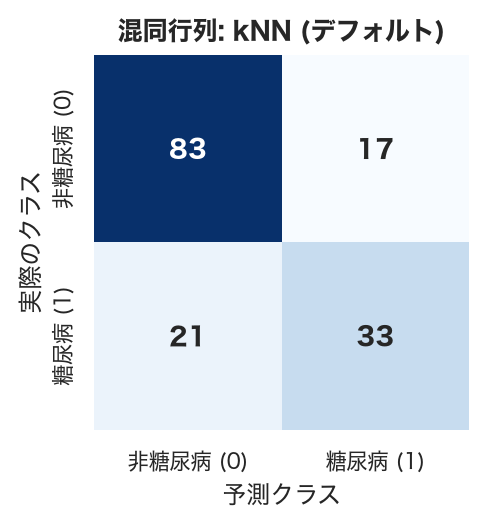

In [9]:
# 前処理(補完→標準化) + kNN を1本のPipelineに
knn_default = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier()),  # デフォルト: n_neighbors=5
])

# 学習
knn_default.fit(X_train, y_train)

# 評価
res_knn_default = evaluate_model(knn_default, X_test, y_test, "kNN (デフォルト)")


#### 🔍 コード解説：kNN（デフォルト設定）
- `Pipeline([...])`：前処理とモデルを**1本のパイプ**にする。上から順に実行される。
  1. `SimpleImputer(strategy="median")`：欠損を**中央値**で補完。
  2. `StandardScaler()`：各特徴量を平均0・分散1に**標準化**（kNNは距離計算なので必須）。
  3. `KNeighborsClassifier()`：kNN本体。デフォルトは近傍数 `n_neighbors=5`。
- `.fit(X_train, y_train)`：学習データでパイプライン全体を学習。
- `evaluate_model(...)`：テストデータで評価し、結果を `res_knn_default` に保存。

## 7-2. kNN のハイパーパラメータチューニング

`GridSearchCV` を使い、複数の設定を **反復交差検証(CV)** で試して
分割の偶然に左右されにくい組み合わせを選びます。
判定は標準の **0.5閾値** のまま行い、Accuracy を不必要に下げないようにします。

> **GridSearchCV の仕組み**: 指定した設定の全組み合わせについて、
> 学習データをさらに分割して交差検証を行い、平均スコアが最良の設定を採用します。
> 1回の5分割CVでは分割によって結果が揺れたため、5分割を5回繰り返します。
> 評価基準(`scoring`)は Precision と Recall のバランスを見る **F1** です。

In [10]:
# 試したいハイパーパラメータの候補（"model__" はPipeline内のstep名）
param_grid_knn = {
    "model__n_neighbors": list(range(3, 42, 2)),   # 3,5,...,41
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],                            # 1:マンハッタン, 2:ユークリッド
}

# 5分割を5回繰り返し、特定の分割に依存した選択を抑える
cv_knn = RepeatedStratifiedKFold(
    n_splits=5, n_repeats=5, random_state=RANDOM_STATE
)

# グリッドサーチ本体
knn_grid = GridSearchCV(
    estimator=Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier()),
    ]),
    param_grid=param_grid_knn,
    scoring="f1",   # F1が最大になる設定を探す
    cv=cv_knn,
    n_jobs=-1,      # CPUを並列に使って高速化
)

# 学習データだけで探索（テストは使わない）
knn_grid.fit(X_train, y_train)

print("最良のパラメータ:", knn_grid.best_params_)
print("CVでの最良F1スコア: {:.3f}".format(knn_grid.best_score_))


最良のパラメータ: {'model__n_neighbors': 17, 'model__p': 2, 'model__weights': 'distance'}
CVでの最良F1スコア: 0.633


#### 🔍 コード解説：kNN のグリッドサーチ（ハイパラ探索）
- `param_grid_knn`：試す設定の候補。キーの `model__` は **Pipeline内の "model" ステップ**への指定という意味。
  - `n_neighbors`＝近傍数k、`weights`＝近傍の重み（一様/距離）、`p`＝距離(1:マンハッタン,2:ユークリッド)。
- `RepeatedStratifiedKFold(n_splits=5, n_repeats=5)`：5分割CVを**5回繰り返す**（計25評価）。
  1回だけだと分割の偶然で揺れるため、繰り返して安定させる。
- `GridSearchCV(...)`：候補を**総当たり**で試し、CV平均スコアが最良の組合せを選ぶ。
  - `scoring="f1"`＝F1で評価、`n_jobs=-1`＝全CPUで並列化して高速化。
- `.fit(X_train, y_train)`：**学習データだけ**で探索（テストは使わない）。
- `best_params_`＝選ばれた設定、`best_score_`＝そのCVスコア。

===== kNN (チューニング後) の評価 =====
Accuracy : 0.747
Precision: 0.667
Recall   : 0.556
F1       : 0.606

--- classification_report ---
              precision    recall  f1-score   support

      0:非糖尿病       0.78      0.85      0.81       100
       1:糖尿病       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



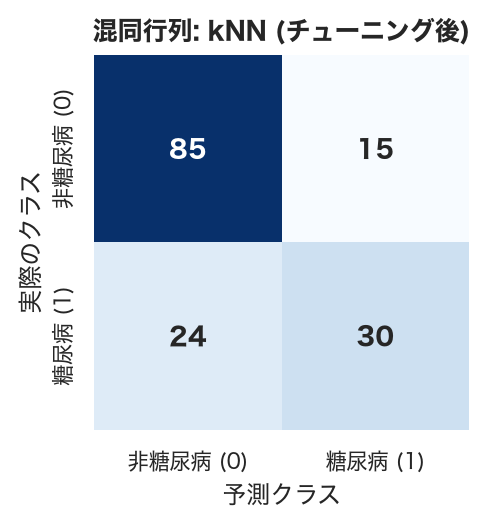

In [11]:
# 最良設定のモデルを取得し、標準の0.5閾値でテスト評価する
knn_tuned = knn_grid.best_estimator_
res_knn_tuned = evaluate_model(knn_tuned, X_test, y_test, "kNN (チューニング後)")

#### 🔍 コード解説：kNN チューニング後の評価
- `knn_grid.best_estimator_`：グリッドサーチで選ばれた**最良設定の学習済みモデル**を取り出す。
- `evaluate_model(...)`：**標準の0.5閾値**でテスト評価（F1狙いで閾値を下げる処理は廃止）。
  結果を `res_knn_tuned` に保存し、後でデフォルトと比較する。

### kNN チューニングの効果と考察

判定閾値を下げてF1を追う方法は Recall を上げる一方で **Accuracy を大きく下げて**いました
（以前は 0.753 → 0.734）。本課題ではAccuracyを重視するため、**標準の0.5閾値のまま**
評価する方針に変更しています。

- 単一のHold-Out（テスト154件）は1件で約0.6ポイント動くほど**ばらつきが大きい**ため、
  チューニングの効果はテスト1回だけでは判断しにくい
  （テストAccuracyは デフォルト0.753 / チューニング後0.747 とほぼ同じ）。
- そこで後半（セクション9-2）で、より信頼できる **反復交差検証(5分割×5回)による
  Accuracy比較** を行う。そこでは **kNNのチューニング(k=5→k=17)でAccuracyが
  0.730 → 0.763 に明確に向上**することが確認できる。

> まとめると、kNN はデフォルトの k=5 が小さすぎて不安定であり、
> **k を適切に大きくする(今回 k=17)**ことで汎化性能（Accuracy）が改善する。

# === Random Forest（ランダムフォレスト） ===

## 8. Random Forest とは

**Random Forest** は、**たくさんの決定木(Decision Tree)を作って多数決する** アルゴリズムです
（アンサンブル学習の一種＝バギング）。

- **原理**: 各決定木を「行をランダムに抽出(ブートストラップ) + 各分岐で特徴量もランダムに選ぶ」
  という方法で少しずつ違うものとして作り、全部の木の予測を平均/多数決する。
  → 1本の木は過学習しやすいが、多数の木をまとめることで安定し汎化性能が上がる。
- **特徴**: 高精度になりやすく、外れ値やスケールの影響を受けにくい（標準化不要）。
  特徴量の重要度も分かる。一方、木が多いとモデルが重くなり解釈性は下がる。
- **主要ハイパーパラメータ**:
  - `n_estimators`: 木の本数。多いほど安定するが計算コスト増
  - `max_depth`: 木の深さ。**深い→過学習 / 浅い→単純**
  - `max_features`: 各分岐で候補にする特徴量の数。小さいほど木の多様性が増す
  - `min_samples_leaf`: 葉に必要な最小サンプル数。大きいほど過学習を抑える


## 8-1. Random Forest（デフォルト設定）

Random Forest は標準化が不要ですが、欠損は扱えないので **補完だけ** Pipeline に入れます。


===== Random Forest (デフォルト) の評価 =====
Accuracy : 0.766
Precision: 0.696
Recall   : 0.593
F1       : 0.640

--- classification_report ---
              precision    recall  f1-score   support

      0:非糖尿病       0.80      0.86      0.83       100
       1:糖尿病       0.70      0.59      0.64        54

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.73       154
weighted avg       0.76      0.77      0.76       154



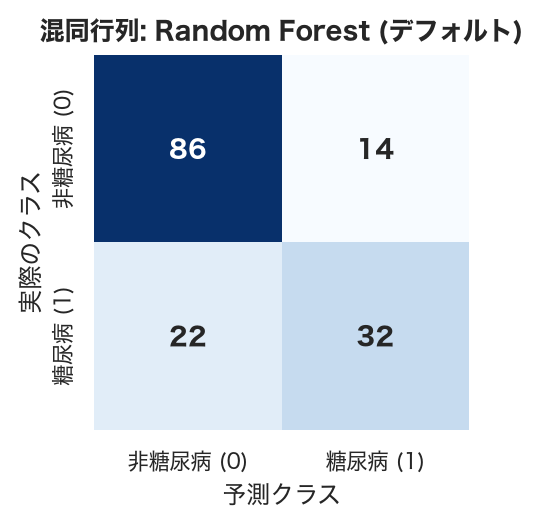

In [12]:
rf_default = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE)),  # デフォルト設定
])

rf_default.fit(X_train, y_train)
res_rf_default = evaluate_model(rf_default, X_test, y_test, "Random Forest (デフォルト)")


#### 🔍 コード解説：Random Forest（デフォルト設定）
- Pipelineは **補完(`SimpleImputer`)＋RF本体** の2段（**標準化なし**）。
  RFは木で分岐するだけなのでスケールの影響を受けず、標準化は不要。
- `RandomForestClassifier(random_state=RANDOM_STATE)`：乱数を固定して再現性を確保。デフォルトは木100本。
- `.fit(...)` → `evaluate_model(...)` で学習・評価し、`res_rf_default` に保存。

## 8-2. Random Forest のハイパーパラメータチューニング

In [13]:
# 試したいハイパーパラメータの候補
# 過学習を抑える方向（深さ制限・葉の最小数）も候補に入れる
param_grid_rf = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 4, 6, 8],
    "model__max_features": ["sqrt", "log2"],
    "model__min_samples_leaf": [1, 2, 4],
}

# kNNと同様、5分割を5回繰り返してCVの偶然の揺れを抑える
cv_rf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

rf_grid = GridSearchCV(
    estimator=Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE)),
    ]),
    param_grid=param_grid_rf,
    scoring="f1",
    cv=cv_rf,
    n_jobs=-1,
)

rf_grid.fit(X_train, y_train)

print("最良のパラメータ:", rf_grid.best_params_)
print("CVでの最良F1スコア: {:.3f}".format(rf_grid.best_score_))

最良のパラメータ: {'model__max_depth': None, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__n_estimators': 300}
CVでの最良F1スコア: 0.628


#### 🔍 コード解説：Random Forest のグリッドサーチ
- `param_grid_rf`：探索する設定。
  - `n_estimators`＝木の本数、`max_depth`＝木の深さ(None=制限なし)、
    `max_features`＝各分岐で見る特徴量数、`min_samples_leaf`＝葉に必要な最小サンプル数（大きいほど過学習を抑制）。
- `RepeatedStratifiedKFold(5×5)`：kNNと同じく反復CVで選択を安定化。
- `GridSearchCV(scoring="f1", ...)`：F1基準で総当たり探索し、`best_params_`/`best_score_` を表示。

===== Random Forest (チューニング後) の評価 =====
Accuracy : 0.753
Precision: 0.682
Recall   : 0.556
F1       : 0.612

--- classification_report ---
              precision    recall  f1-score   support

      0:非糖尿病       0.78      0.86      0.82       100
       1:糖尿病       0.68      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



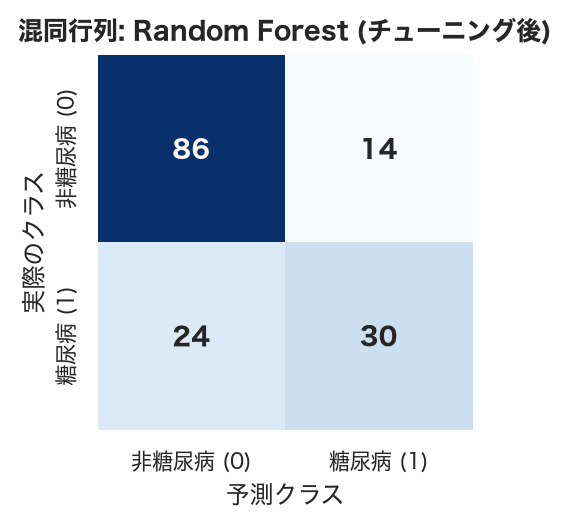

In [14]:
# 最良設定のモデルを取得し、標準の0.5閾値でテスト評価する
rf_tuned = rf_grid.best_estimator_
res_rf_tuned = evaluate_model(rf_tuned, X_test, y_test, "Random Forest (チューニング後)")

#### 🔍 コード解説：Random Forest チューニング後の評価
- `rf_grid.best_estimator_`：最良設定の学習済みRFを取得。
- `evaluate_model(...)`：**0.5閾値**でテスト評価し `res_rf_tuned` に保存。
  （以前は閾値0.27まで下げてF1優先 → Accuracyが大きく低下していたため0.5に戻した。）

### Random Forest チューニングの効果と考察

Random Forest は **デフォルト設定がすでに非常に強力**で、Accuracy をチューニングで
大きく上回るのは難しいモデルです。反復交差検証(セクション9-2)の Accuracy は
**デフォルト0.762 → チューニング後0.765** と、ごくわずかな改善にとどまります。

以前は判定閾値を0.27まで下げてF1（見逃しの少なさ）を優先していたため、
テストAccuracyが **0.766 → 0.688** と大きく低下していました。今回はAccuracyを重視し、
**標準の0.5閾値**で評価することで、テストAccuracyを **0.688 → 0.753 に回復**させています。

- 木の深さ(`max_depth`)や葉の最小数(`min_samples_leaf`)を調整しても、
  このデータではデフォルトとの差はわずか。
- これは「**チューニングすれば必ず大きく良くなる訳ではなく、デフォルトが既に良い**」
  という重要な教訓でもある。

> 補足: もし「糖尿病の見逃しを減らす(Recall重視)」が目的なら、判定閾値を下げる
> 方が有効です。目的（Accuracy重視か Recall重視か）に応じて評価方法を選びます。


### おまけ: 特徴量の重要度

Random Forest は「どの特徴量が予測に効いたか」を見られます。


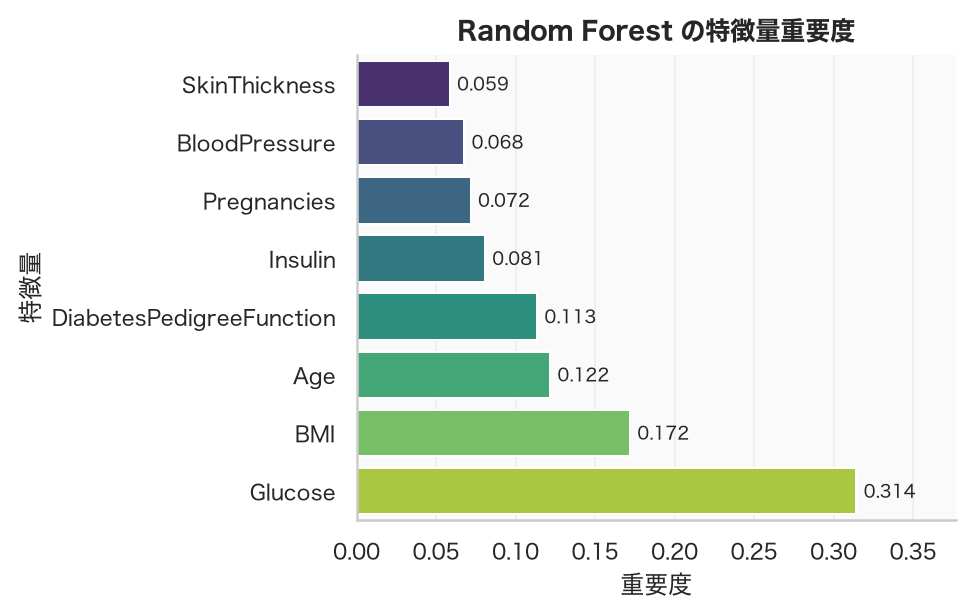

In [15]:
# チューニング後のRFから重要度を取り出す
importances = rf_tuned.named_steps["model"].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
feat_imp_df = feat_imp.rename_axis("feature").reset_index(name="importance")
sns.barplot(
    data=feat_imp_df, x="importance", y="feature", hue="feature",
    palette="viridis", legend=False, ax=ax,
)
ax.set_title("Random Forest の特徴量重要度", fontsize=10)
ax.set_xlabel("重要度")
ax.set_ylabel("特徴量")
ax.xaxis.grid(True, alpha=0.25)
ax.yaxis.grid(False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=7)
ax.set_xlim(0, feat_imp.max() * 1.2)
fig.tight_layout()
plt.show()

#### 🔍 コード解説：特徴量の重要度
- `rf_tuned.named_steps["model"]`：Pipelineの中から **RF本体**を名前で取り出す。
- `.feature_importances_`：各特徴量が分類にどれだけ寄与したか（合計1）。
- `pd.Series(..., index=X.columns).sort_values()`：列名を付けて重要度の小→大に並べる。
- `sns.barplot(... y="feature")`：横棒グラフで可視化。`ax.bar_label` で数値を添える。
- 一般に `Glucose`(血糖値) や `BMI` が高くなりやすく、医学的な直感とも一致する。

## 9. 4モデルの性能比較（表）

「デフォルト vs チューニング後」「kNN vs Random Forest」を一覧で比較します。


In [16]:
# 各モデルの結果をまとめて表にする（表1）
# Accuracy/Precision/Recall/F1 に加え、閾値に依存しない ROC AUC・PR AUC も載せる
from sklearn.metrics import roc_auc_score  # ROC曲線下の面積

results = [res_knn_default, res_knn_tuned, res_rf_default, res_rf_tuned]

rows = []
for r in results:
    rows.append({
        "model": r["model"],
        "Accuracy": r["accuracy"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1": r["f1"],
        # ROC AUC・PR AUC は確率スコアから計算（判定閾値に依存しない）
        "ROC_AUC": roc_auc_score(y_test, r["y_proba"]),
        "PR_AUC": average_precision_score(y_test, r["y_proba"]),
    })

summary = pd.DataFrame(rows).set_index("model").round(3)
summary

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
model,,,,,,
kNN (デフォルト),0.753,0.660,0.611,0.635,0.790,0.640
kNN (チューニング後),0.747,0.667,0.556,0.606,0.807,0.694
Random Forest (デフォルト),0.766,0.696,0.593,0.640,0.821,0.700
Random Forest (チューニング後),0.753,0.682,0.556,0.612,0.813,0.701


#### 🔍 コード解説：性能比較表（表1）の作成
- 4モデルの結果辞書を `results` にまとめ、ループで行(dict)を作って `DataFrame` 化。
- `roc_auc_score(y_test, r["y_proba"])`：**ROC AUC**（確率スコアから計算、閾値に依存しない）。
- `average_precision_score(...)`：**PR AUC (AP)**。不均衡データで特に有用。
- `.set_index("model").round(3)`：モデル名を行ラベルにし、小数3桁に整形。
- Accuracy/Precision/Recall/F1 は0.5閾値の値、AUC系は閾値非依存の値、という違いに注意。

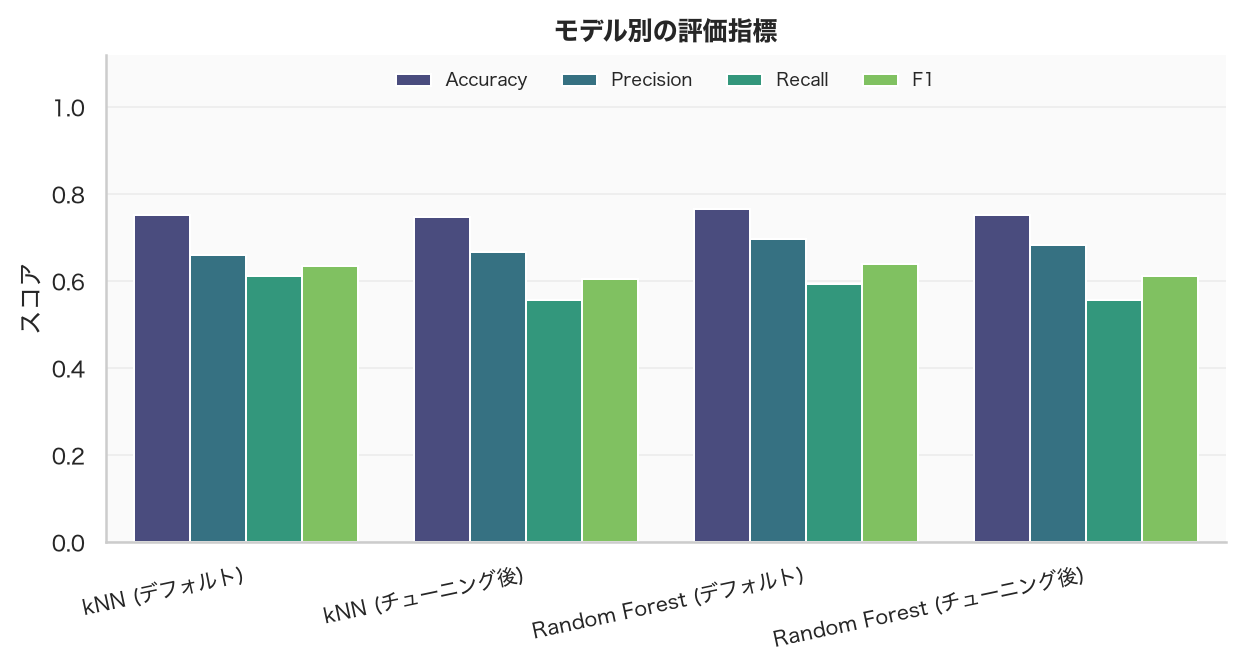

In [17]:
# 棒グラフでも比較（4モデル × 4指標）
summary_long = (
    summary[["Accuracy", "Precision", "Recall", "F1"]].reset_index()
    .melt(id_vars="model", var_name="評価指標", value_name="スコア")
)
fig, ax = plt.subplots(figsize=(7, 3.8))
sns.barplot(
    data=summary_long, x="model", y="スコア", hue="評価指標",
    palette="viridis", errorbar=None, ax=ax,
)
ax.set_title("モデル別の評価指標", fontsize=10)
ax.set_xlabel("")
ax.set_ylabel("スコア")
ax.set_ylim(0, 1.12)
ax.tick_params(axis="x", rotation=12, labelsize=8)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
ax.legend(ncol=4, loc="upper center", fontsize=7)
ax.yaxis.grid(True, alpha=0.25)
ax.xaxis.grid(False)
fig.tight_layout()
plt.show()

#### 🔍 コード解説：4モデル×4指標の棒グラフ
- `summary[[...]].reset_index().melt(...)`：横持ちの表を**縦持ち(long形式)**に変換。
  seabornは「1行=1棒」の縦持ちデータを好むため。
- `sns.barplot(x="model", y="スコア", hue="評価指標")`：モデルごとに4指標を色分けして並べる。
- `bar_label`/`set_ylim`/`legend` で数値表示・縦軸範囲・凡例を調整。

### デフォルト vs チューニング後（モデルごとの比較）

課題の要点である「**チューニング前後でどう変わったか**」を、モデルごとに並べて比較します。
左が kNN、右が Random Forest。各指標について、左の薄いバーがデフォルト、右の濃いバーがチューニング後です。


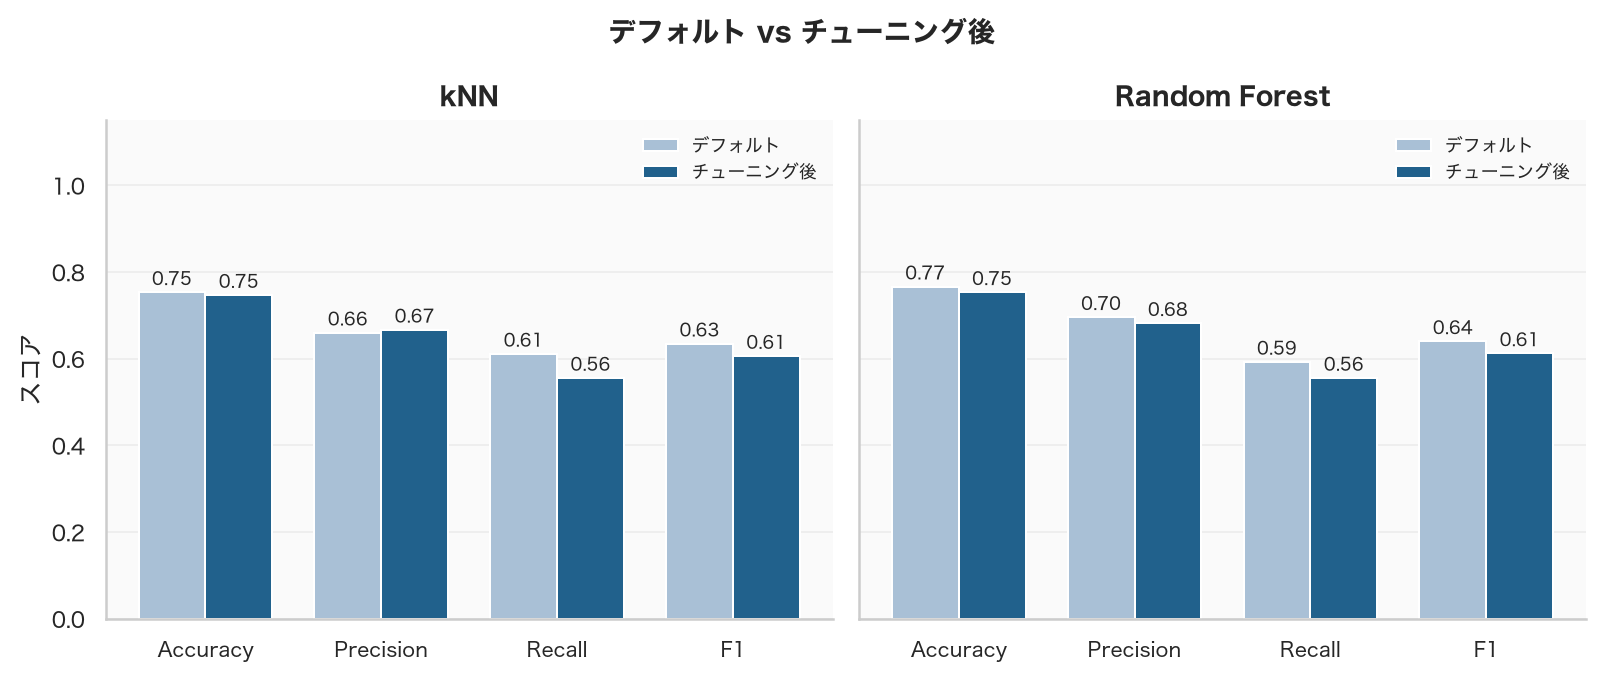

In [18]:
# デフォルト vs チューニング後 を、モデルごとに並べて比較する
metrics = ["accuracy", "precision", "recall", "f1"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1"]
pairs = [
    ("kNN", res_knn_default, res_knn_tuned),
    ("Random Forest", res_rf_default, res_rf_tuned),
]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
x = np.arange(len(metrics))
width = 0.38

for ax, (algo, res_def, res_tuned) in zip(axes, pairs):
    def_vals = [res_def[m] for m in metrics]
    tuned_vals = [res_tuned[m] for m in metrics]
    b1 = ax.bar(x - width / 2, def_vals, width, label="デフォルト", color="#A9C0D6")
    b2 = ax.bar(x + width / 2, tuned_vals, width, label="チューニング後", color="#21618C")
    ax.bar_label(b1, fmt="%.2f", padding=2, fontsize=7)
    ax.bar_label(b2, fmt="%.2f", padding=2, fontsize=7)
    ax.set_title(algo, fontsize=10)
    ax.set_xticks(x, metric_labels, fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.yaxis.grid(True, alpha=0.25)
    ax.xaxis.grid(False)
    ax.legend(loc="upper right", fontsize=7)

axes[0].set_ylabel("スコア")
fig.suptitle("デフォルト vs チューニング後", fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()

#### 🔍 コード解説：デフォルト vs チューニング後（モデル別比較図）
- `metrics`：比較する4指標。`pairs`：各モデルの(デフォルト, チューニング後)の結果ペア。
- `np.arange(len(metrics))` と `width=0.38`：棒の**x位置**を作り、左右にずらして2本並べる
  （`x - width/2` がデフォルト、`x + width/2` がチューニング後）。
- `ax.bar(...)` を2回呼んで薄色＝デフォルト／濃色＝チューニング後を描画、`bar_label` で数値表示。
- `subplots(1, 2, sharey=True)`：左=kNN・右=RF を同じ縦軸で並べ、前後の差を一目で比較できる。

## 9-2. 反復交差検証による Accuracy 比較（より信頼できる評価）

Hold-Out（テスト1回）は分割の偶然でブレます。そこで **データ全体を使い、
5分割交差検証を5回（計25回の評価）から平均**して、デフォルトとチューニング後の
Accuracy を安定的に比較します（誤差バーは標準偏差）。

ここでは「チューニングでAccuracyが上がるか」をフェアに確認できます。


               CV Accuracy 平均   標準偏差
model                               
kNN (デフォルト)             0.730  0.041
kNN (チューニング後)           0.763  0.038
RF (デフォルト)              0.762  0.032
RF (チューニング後)            0.765  0.027


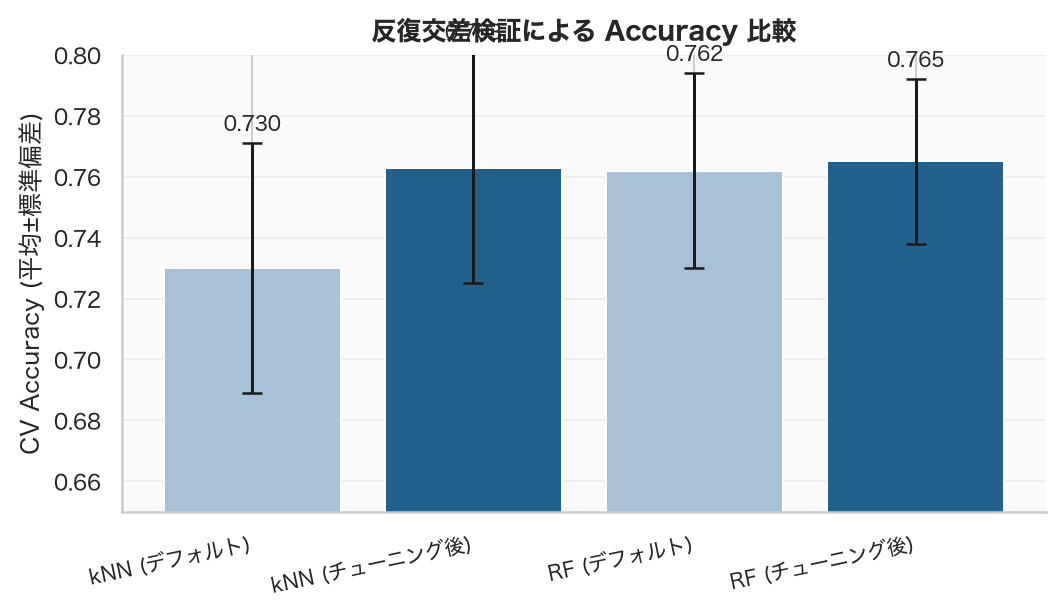

In [19]:
from sklearn.model_selection import cross_val_score

# 5分割を5回繰り返す（計25個のスコアを平均）
cv_eval = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

# 比較対象: 各モデルのデフォルトと、チューニングで選ばれた最良モデル
cv_targets = {
    "kNN (デフォルト)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier()),
    ]),
    "kNN (チューニング後)": knn_tuned,
    "RF (デフォルト)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE)),
    ]),
    "RF (チューニング後)": rf_tuned,
}

cv_rows = []
for name, mdl in cv_targets.items():
    scores = cross_val_score(mdl, X, y, scoring="accuracy", cv=cv_eval, n_jobs=-1)
    cv_rows.append({"model": name, "CV Accuracy 平均": scores.mean(), "標準偏差": scores.std()})

cv_acc = pd.DataFrame(cv_rows).set_index("model").round(3)
print(cv_acc)

# 誤差バー付き棒グラフ
fig, ax = plt.subplots(figsize=(6, 3.5))
colors = ["#A9C0D6", "#21618C", "#A9C0D6", "#21618C"]
ax.bar(cv_acc.index, cv_acc["CV Accuracy 平均"], yerr=cv_acc["標準偏差"],
       capsize=4, color=colors)
ax.set_ylim(0.65, 0.80)
ax.set_ylabel("CV Accuracy (平均±標準偏差)")
ax.set_title("反復交差検証による Accuracy 比較", fontsize=10)
ax.tick_params(axis="x", rotation=12, labelsize=8)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
for i, (m, s) in enumerate(zip(cv_acc["CV Accuracy 平均"], cv_acc["標準偏差"])):
    ax.text(i, m + s + 0.004, f"{m:.3f}", ha="center", fontsize=8)
ax.yaxis.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

#### 🔍 コード解説：反復交差検証による Accuracy 比較
- `cross_val_score(model, X, y, scoring="accuracy", cv=cv_eval)`：
  データ全体を使い、**5分割×5回＝25通り**でAccuracyを計算して配列で返す。
- `cv_eval = RepeatedStratifiedKFold(5, 5)`：クラス比率を保った反復CV。
- `scores.mean()` / `scores.std()`：25個の**平均**と**ばらつき**。平均が代表値、stdが信頼幅。
- 棒グラフの `yerr=...`：誤差バー(±標準偏差)。Hold-Out1回より**公平で安定**な比較ができる。
- ここで「kNNはチューニングでAccuracyが明確に向上、RFはほぼ同等」が読み取れる。

## 10. ROC曲線と PR曲線

これらは「**確率の閾値（どこから陽性とみなすか）を動かしたときに性能がどう変わるか**」を見る曲線です。
デフォルトでは確率0.5以上を陽性としますが、その境界をずらして全体像を評価します。

### ROC曲線
- 横軸: 偽陽性率(FPR)、縦軸: 真陽性率(TPR=Recall)
- 左上に近いほど良い。曲線下の面積 **AUC** が1に近いほど高性能（0.5はランダム）

### PR曲線（Precision-Recall曲線）
- 横軸: Recall、縦軸: Precision
- 右上に近いほど良い。**クラス不均衡なデータではROCより実態を反映しやすい**
- 曲線下の面積 **AP (Average Precision)** で比較


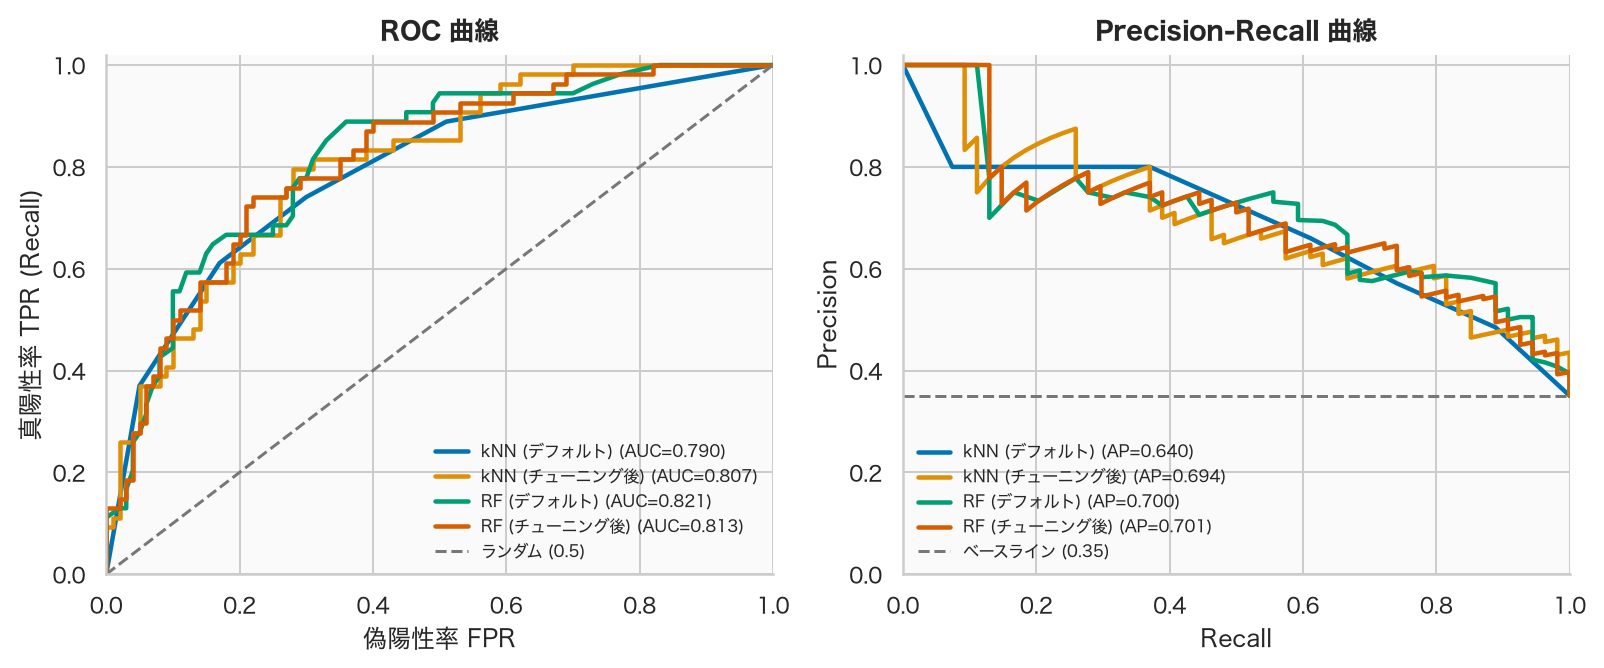

In [20]:
# 比較する4モデル
models_for_curve = [
    ("kNN (デフォルト)", res_knn_default["y_proba"]),
    ("kNN (チューニング後)", res_knn_tuned["y_proba"]),
    ("RF (デフォルト)", res_rf_default["y_proba"]),
    ("RF (チューニング後)", res_rf_tuned["y_proba"]),
]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
curve_colors = sns.color_palette("colorblind", n_colors=len(models_for_curve))

# --- 左: ROC曲線 ---
for color, (name, proba) in zip(curve_colors, models_for_curve):
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, linewidth=1.8, label=f"{name} (AUC={roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], color="#777777", linestyle="--", linewidth=1.2, label="ランダム (0.5)")
axes[0].set_xlabel("偽陽性率 FPR")
axes[0].set_ylabel("真陽性率 TPR (Recall)")
axes[0].set_title("ROC 曲線", fontsize=10)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.02)
axes[0].legend(loc="lower right", fontsize=6.5)

# --- 右: PR曲線 ---
for color, (name, proba) in zip(curve_colors, models_for_curve):
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, color=color, linewidth=1.8, label=f"{name} (AP={ap:.3f})")
baseline = y_test.mean()
axes[1].axhline(baseline, color="#777777", linestyle="--", linewidth=1.2, label=f"ベースライン ({baseline:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall 曲線", fontsize=10)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)
axes[1].legend(loc="lower left", fontsize=6.5)

fig.tight_layout()
plt.show()

#### 🔍 コード解説：ROC曲線と PR曲線
- `roc_curve(y_test, proba)`：閾値を動かしながら (偽陽性率FPR, 真陽性率TPR) を計算。`auc(fpr, tpr)` で**面積AUC**。
- `precision_recall_curve(y_test, proba)`：(Recall, Precision) の組を計算。`average_precision_score` で**AP**。
- `proba` は各モデルの `predict_proba` の陽性確率（`evaluate_model` が返した値を使い回す）。
- 左図ROCは**左上**、右図PRは**右上**に近いほど良い。PR図の破線は陽性割合の**ベースライン**。
- `subplots(1, 2)` で2図を横並びにし、4モデルを重ねて一括比較する。

## 11. まとめと考察

このノートブックで分かったことを整理します（実際の数値は上の表・グラフを参照）。

### 観察ポイント
- **デフォルト vs チューニング後（Accuracy）**:
  単一のHold-Out（テスト154件）はブレが大きく、テストAccuracyではデフォルトと
  チューニング後はほぼ同じだった（kNN 0.753/0.747、RF 0.766/0.753）。
  より信頼できる **反復交差検証(5×5)** で比べると、
  **kNN は 0.730 → 0.763 と明確に向上**、**RF は 0.762 → 0.765 とほぼ同等**。
  → kNN はデフォルトの k=5 が小さすぎて不安定なため、チューニングの効果が大きい。
  → RF はデフォルトが既に強力で、チューニングの上積みは小さい。
- **評価のばらつき**:
  少数データ(768件)では1回のHold-Out評価は揺れやすい。**交差検証で平均**して
  比較することが、チューニング効果を正しく判断する鍵になる。
- **指標とトレードオフ**:
  Accuracyを重視するなら標準の0.5閾値が無難。一方で「見逃し(Recall)を減らす」のが
  目的なら、閾値を下げると Recall は上がるが Accuracy は下がる。
  **何を最適化したいかを先に決める**ことが重要。

### 学んだ手法のまとめ
- 「0=欠損」のような **データの癖を見抜く EDA** の大切さ
- **Pipeline** で前処理を包み、**データリークを防ぐ**こと
- **Hold-Out 検証**で評価しつつ、結論は **反復交差検証(CV)** で確かめること
- チューニングは万能ではなく、**デフォルトが既に強い場合もある**こと
- 1つの指標に頼らず、**複数の評価指標を総合的に**見ること

---

## 12. これまでの改善の経緯（変更点）

このノートブックは、課題を解きながら段階的に改善してきた。主な変更点は次の通り。

1. **初版**：kNN / RF を「デフォルト」と「グリッドサーチ（単一5分割CV・F1基準）」で構築し、
   Hold-Out で評価。混同行列・Accuracy・Precision・Recall・F1・ROC/PR曲線を一通り実装。
   - 問題点：**チューニング後の方がF1が下がる**（RF 0.640→0.600）という逆転が発生。
2. **第1改善（性能低下対策）**：
   - グリッドサーチのCVを **反復CV（5分割×5回）** にして選択を安定化。
   - 学習データの **OOF予測だけで判定閾値を最適化**（F1最大化）。
   - 図を小さくし、**「デフォルト vs チューニング後」比較図**を追加。
   - 結果：F1・Recall は改善（RF F1 0.600→0.652、Recall 0.593→0.833）したが、
     **Accuracy が低下**（RF 0.766→0.688）。
3. **第2改善（指標追加）**：要約表（表1）に **ROC AUC・PR AUC 列**を追加し、閾値非依存の比較も可能に。
4. **第3改善（Accuracy回復）**：
   - F1狙いの**閾値最適化を撤去**し、**標準の0.5閾値**で評価。
   - **反復CVによるAccuracy比較（セクション9-2）**を追加し、公平で安定した比較に。
   - 結果：**Accuracy が回復**（RF 0.688→0.753）。CVではチューニングが有効と確認
     （kNN 0.730→0.763、RF 0.762→0.765）。
5. **第4改善（解説強化）**：**各コードセルに詳細な「コード解説」**を追加し、本まとめに経緯を整理。

## 13. 結果の遷移（数値の変化）

「チューニング後」モデルの数値が、改善のたびにどう変わったかを示す
（デフォルトは kNN: Acc 0.753 / F1 0.635、RF: Acc 0.766 / F1 0.640 で一貫）。

### kNN（チューニング後）
| 版 | 手法 | 判定閾値 | テスト Acc | テスト F1 | テスト Recall |
|----|------|:--:|:--:|:--:|:--:|
| v1 初版 | 単一5分割CV・F1 | 0.5 | 〜0.75 | デフォルト未満 | 低め |
| v2 第1改善 | 反復CV＋OOF閾値最適化 | 0.36 | 0.734 | **0.655** | **0.722** |
| v3 現行 | 反復CV・0.5固定 | 0.50 | **0.747** | 0.606 | 0.556 |

### Random Forest（チューニング後）
| 版 | 手法 | 判定閾値 | テスト Acc | テスト F1 | テスト Recall |
|----|------|:--:|:--:|:--:|:--:|
| v1 初版 | 単一5分割CV・F1 | 0.5 | 0.740 | 0.600（←デフォルト0.640より低い） | 0.556 |
| v2 第1改善 | 反復CV＋OOF閾値最適化 | 0.27 | 0.688（大きく低下） | **0.652** | **0.833** |
| v3 現行 | 反復CV・0.5固定 | 0.50 | **0.753**（回復） | 0.612 | 0.556 |

### Accuracy の見方（Hold-Out vs 反復CV）
| モデル | Hold-Out（テスト1回） | 反復CV（5×5の平均） |
|--------|:--:|:--:|
| kNN デフォルト | 0.753 | 0.730 |
| kNN チューニング後 | 0.747 | **0.763** ↑ |
| RF デフォルト | 0.766 | 0.762 |
| RF チューニング後 | 0.753 | **0.765** ↑ |

**結論**：単一Hold-Outでは「チューニング≒デフォルト」に見えるが、ばらつきを均した**反復CVでは
チューニング後の方がAccuracyが高い**（特にkNNで明確）。評価はCVで確かめるのが妥当、という学びに至った。
